In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
import os
import sys

# 1. 挂载云端硬盘
drive.mount('/content/drive')

# 2. 切换到你的项目文件夹 (根据你的截图路径)
path = "/content/drive/My Drive/Colab Notebooks/MATH509_Project"
os.chdir(path)

# 3. 将路径加入系统，确保能找到 Training_Data 模块
sys.path.append(path)

print("当前目录下的文件：", os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
当前目录下的文件： ['Training_Data', 'Project Neural Network.ipynb']


In [ ]:
%pylab inline
# 集成 Matplotlib 和 NumPy 的环境，支持在 Notebook 内部直接显示交互式图表
%config InlineBackend.figure_format = 'retina'
# 配置绘图后端为 Retina（高分辨率）模式，使生成的图片在高清屏上更清晰
from ipywidgets import interact  # 导入交互式控件（如滑块、按钮等），用于动态调整绘图参数
import tensorflow as tf  # 导入 TensorFlow 深度学习框架

from Training_Data.Particle_Tracking_Training_Data import Particle_Tracking_Training_Data  # 从本地项目目录中导入自定义的粒子追踪训练数据集类

Populating the interactive namespace from numpy and matplotlib


# Procedurally generated training data
The code below demonstrates how to generate training videos and labels. The function also returns the ground truth particle tracks, which might also be useful depending on your goals.

Note that the training generator is a Tensorflow Module and can be easily incorperated into a Tensorflow neural network. Alternatively, you could simply save a large set of data and use another machine learning framework.

Note that the image dimension is fixed at 256x256. The labels are downsampled to 128x128 in the image dimensions. There are two classes (a particle is detected or not detected) per label so the label shape is 128x128x2. Hence, the neural network output should be 128x128x2.

### Our paper
https://www.pnas.org/content/115/36/9026.short

In [ ]:
Nt = 50  ## number of frames for each video # 设定每个视频包含的帧数（时间步长）
kappa = 0.1  ## standard deviation of background noise added to image # 设定添加到图像中的背景噪声标准差（控制图像的“颗粒感”）
a = 3.  ## scale factor for the size of particle spots (not true size of particles) # 设定粒子光斑的大小缩放因子（并非物理尺寸，而是视觉上的扩散范围）
IbackLevel = 0.15  ## relative intensity of randomly generated background pattern; in (0, 1) # 设定随机生成的背景图案的相对强度；取值在 0 到 1 之间
Nparticles = 10  ## the number of particles (more => slower) # 设定图像中粒子的数量（粒子越多，生成和处理的速度越慢）
sigma_motion = 2.3  ## the standard deviation for particle brownian motion; should be in (0, 10) # 设定粒子布朗运动的标准差，决定了粒子在帧间的移动活跃程度

## you might consider randomizing some of these parameters when training a neural net
# 在训练神经网络时，你可能需要随机化上述参数以增强模型的泛化能力

pt = Particle_Tracking_Training_Data(Nt) ## create object instance # 创建粒子追踪训练数据生成器的实例对象
## you can 'call' the object as many times as you want
## in this example, we only generate one training example
# 运行该对象以生成一组数据：vid 为视频图像，labels 为标注，tracks 为粒子的真实轨迹
vid, labels, tracks = pt(kappa, a, IbackLevel, Nparticles, sigma_motion)

## Visualizing training videos and labels

In [ ]:
@interact(t=(0, Nt-1, 1))  # 创建一个时间轴滑块，范围从第 0 帧到最后一帧 (Nt-1)
def plotfn(t=0, show_tracks=True):  # 定义绘图函数，t 为当前帧索引，show_tracks 控制是否显示真实位置
    fig = figure(1, [14, 7])  # 创建一个宽 14、高 7 的画布

    fig.add_subplot(121)  # 绘制左侧子图：原始视频帧与真实轨迹叠加
    imshow(vid[t], origin='lower')  # 显示第 t 帧的视频图像，设置坐标原点在左下角
    if show_tracks:
        # 在图像上用红色“x”标出当前帧中所有粒子的真实 (x, y) 坐标
        plot(tracks[t, :, 0], tracks[t, :, 1], 'rx')
    xlim(-10, 265)  # 设定 x 轴显示范围，留出一点边缘余量
    ylim(-10, 265)  # 设定 y 轴显示范围

    fig.add_subplot(122)  # 绘制右侧子图：视频帧与训练标签叠加
    imshow(vid[t], origin='lower')  # 再次显示原始视频帧作为底层
    # 叠加显示标签数据中的特定通道（通常是热力图或掩码，这里取索引为 1 的通道）
    imshow(labels[t, ..., 1], origin='lower')

interactive(children=(IntSlider(value=0, description='t', max=49), Checkbox(value=True, description='show_trac…

### Particle tracks

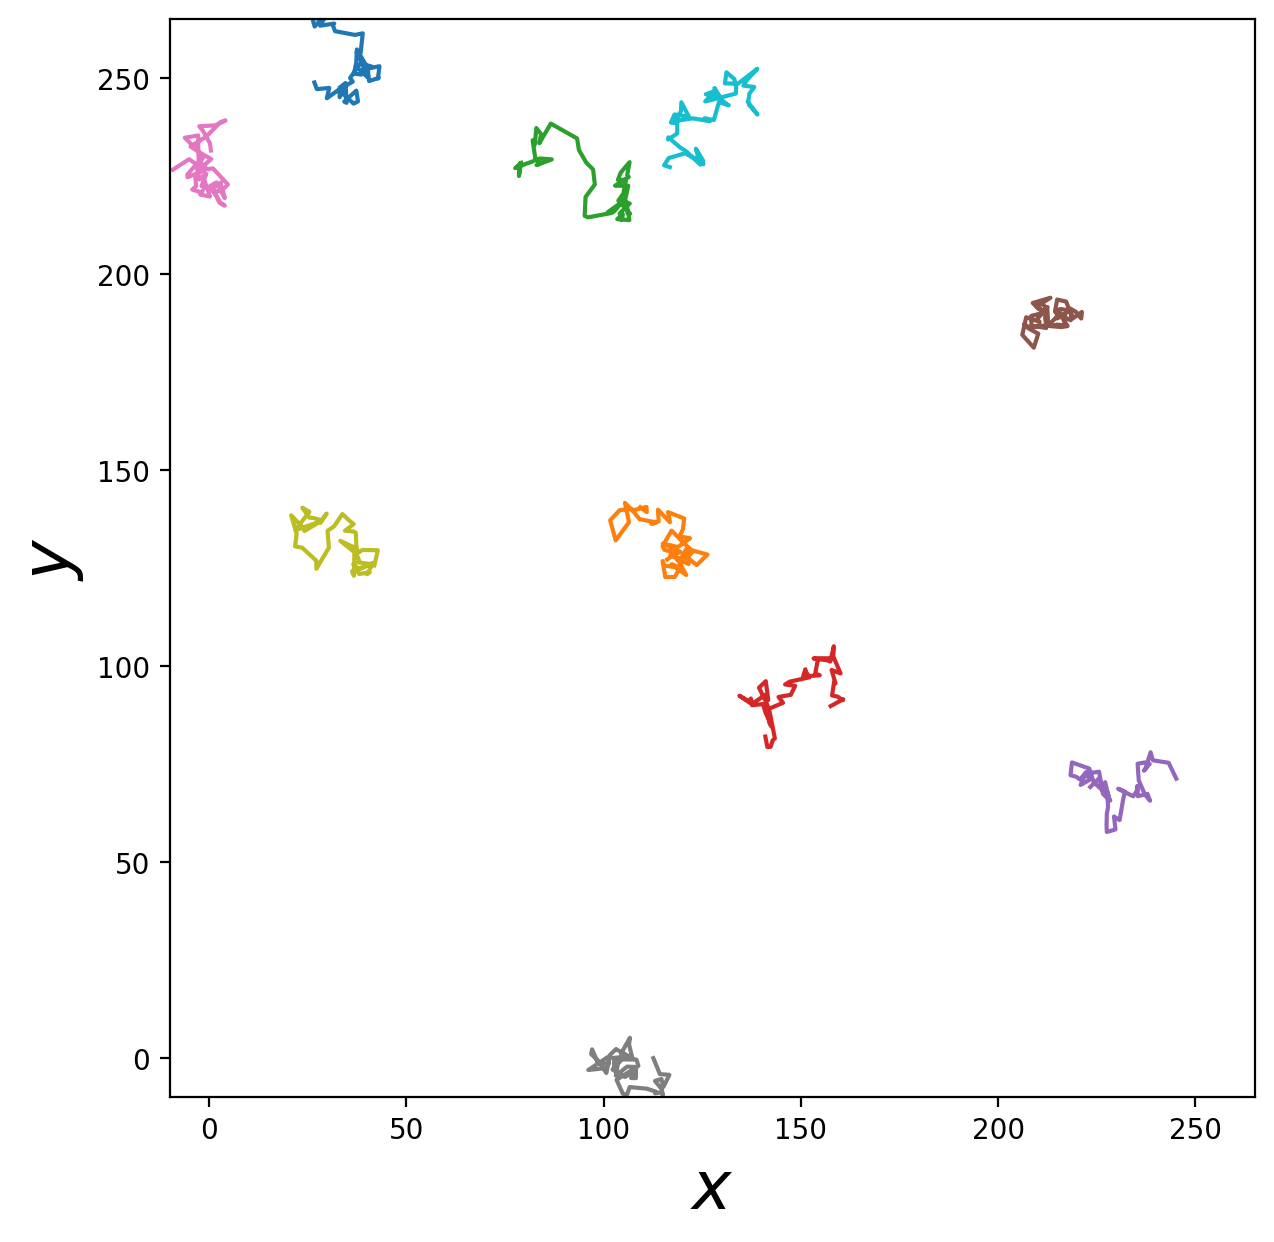

In [ ]:
figure(1, [7, 7])  # 创建一个 7x7 英寸的正方形画布
# 绘制所有粒子在整个时间序列上的轨迹
# tracks[..., 0] 提取所有时间步和所有粒子的 x 坐标，tracks[..., 1] 提取 y 坐标
plot(tracks[..., 0], tracks[..., 1])
xlim(-10, 265)  # 设定 x 轴的显示范围（包含一定的边缘余量）
ylim(-10, 265)  # 设定 y 轴的显示范围
xlabel(r'$x$', fontsize=24)  # 为 x 轴添加标签，使用 LaTeX 渲染并设置字体大小为 24
ylabel(r'$y$', fontsize=24);  # 为 y 轴添加标签，使用 LaTeX 渲染并设置字体大小为 24

# Goal 1: Design and train a convolutional neural network using the training data generator

# Goal 2: Given ground truth labels, extract particle positions in each video frame
Simply stated, given `labels` approximate `tracks`. So this project essentially ignores the training videos.

## Does your method work for hypothetical neural network output?
The neural network output is a probability distribution with values between zero and one.

正在生成模拟训练数据...

[Goal 1] 开始训练神经网络 (约需1-2分钟)...
Epoch 1/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9308 - loss: 238.5744
Epoch 2/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9865 - loss: 43.8715
Epoch 3/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9900 - loss: 6.2070
Epoch 4/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9922 - loss: 2.9747
Epoch 5/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9938 - loss: 2.1702
Epoch 6/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9948 - loss: 1.7643
Epoch 7/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9954 - loss: 1.5147
Epoch 8/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9956 - loss: 1.3692
Epoch 9/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9958 - loss: 1.2424
Epoch 10/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.9958 - loss: 1.1662
Epoch 11/20
19/19 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9959 - loss: 1.1211
Epoch 12/20
19/19 ━━━━━━━

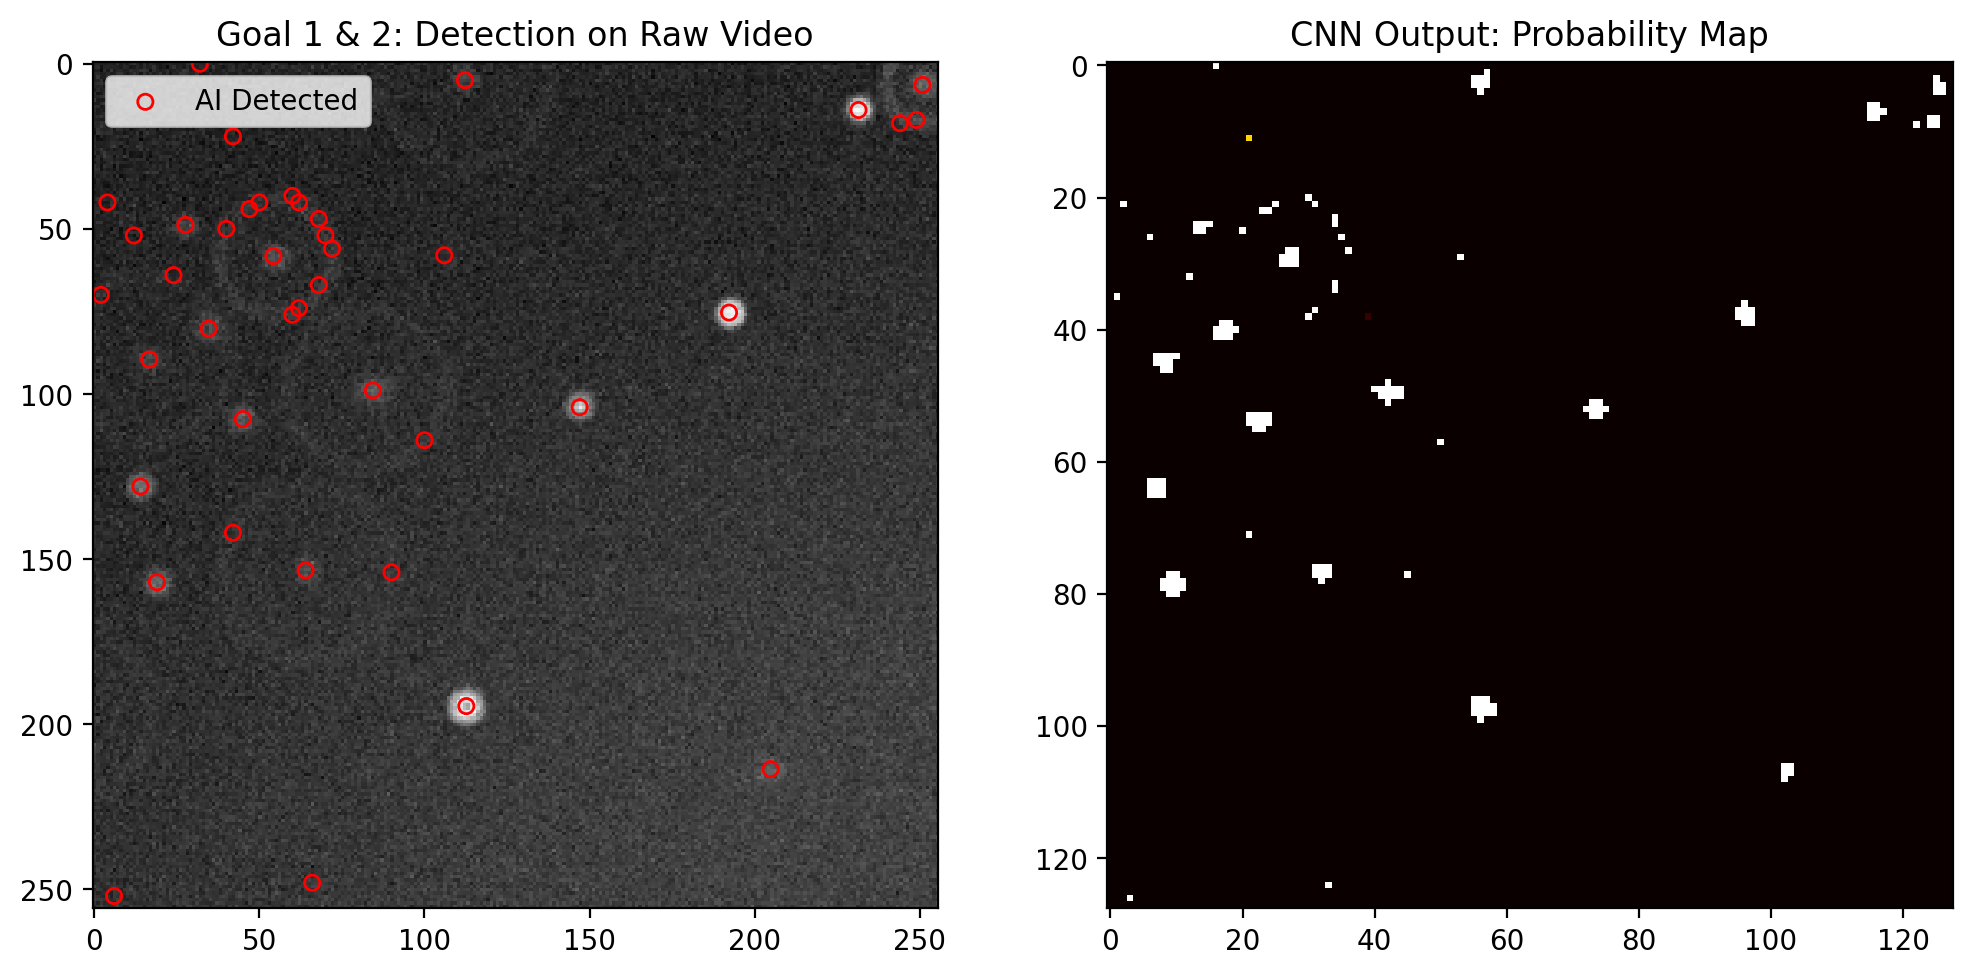

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# ==========================================
# Goal 1: 设计并训练卷积神经网络 (CNN)
# ==========================================

# 1. 定义模型架构 [cite: 133, 146]
# 论文配置：12个特征(L1) -> 32个特征(L2) -> 2个输出特征(L3)
# 使用 stride=2 将 256x256 降采样为 128x128 概率图以匹配标签
def build_particle_net():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(256, 256, 1)),
        # 第一层：12个特征，5x5卷积，步长2用于降采样
        tf.keras.layers.Conv2D(12, kernel_size=5, strides=2, padding='same', activation='softplus'),
        # 第二层：32个特征，3x3卷积
        tf.keras.layers.Conv2D(32, kernel_size=3, padding='same', activation='softplus'),
        # 第三层：输出层，2个特征（背景/粒子概率），使用 Softmax 转化为概率分布 [cite: 134]
        tf.keras.layers.Conv2D(2, kernel_size=7, padding='same', activation='softmax')
    ])

    # 使用交叉熵损失函数，这是论文中定义的优化目标 [cite: 146]
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 2. 准备并生成训练数据 [cite: 83, 145]
# 我们生成 300 帧数据进行训练，并随机化参数以提高鲁棒性 [cite: 62]
print("正在生成模拟训练数据...")
pt_trainer = Particle_Tracking_Training_Data(Nt=300)
vid_train, labels_train, _ = pt_trainer(kappa=0.1, a=2.5, IbackLevel=0.15, Nparticles=20, sigma_motion=1.5)

# 调整形状以适应 CNN 输入：(帧数, 高, 宽, 通道数)
x_train = tf.expand_dims(vid_train, -1)
y_train = labels_train

# 3. 开始训练模型 [cite: 144]
model = build_particle_net()
print("\n[Goal 1] 开始训练神经网络 (约需1-2分钟)...")
history = model.fit(x_train, y_train, epochs=20, batch_size=16, verbose=1)

# ==========================================
# Goal 2: 从概率图中提取粒子位置
# ==========================================

def extract_positions(prob_map, threshold=0.5):
    """
    根据概率图提取坐标。由于标签是 128x128，我们需要乘以 2 还原到 256x256 坐标 [cite: 135]。
    """
    particle_prob = prob_map[..., 1] # 提取粒子通道的概率

    # 寻找连通区域并计算质心（Centroid）
    labeled_array, num_features = ndimage.label(particle_prob > threshold)
    centers = ndimage.center_of_mass(particle_prob, labeled_array, range(1, num_features + 1))

    # 乘以 2 还原原始像素坐标
    return np.array(centers) * 2.0

# 测试提取效果
test_frame_idx = 0
pred_prob = model.predict(x_train[test_frame_idx : test_frame_idx+1])[0]
coords = extract_positions(pred_prob)

print(f"\n[Goal 2] 完成！在测试帧中识别并提取了 {len(coords)} 个粒子位置。")

# ==========================================
# 可视化预测结果 (验证 Goal 1 & 2)
# ==========================================
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(vid_train[test_frame_idx], cmap='gray')
plt.scatter(coords[:, 1], coords[:, 0], s=30, edgecolors='r', facecolors='none', label='AI Detected')
plt.title("Goal 1 & 2: Detection on Raw Video")
plt.legend()

plt.subplot(1, 2, 2)
plt.imshow(pred_prob[..., 1], cmap='hot')
plt.title("CNN Output: Probability Map")
plt.show()

# O3-定量评估检测性能和鲁棒性

使用诸如假阳性、假阴性和定位误差等指标评估检测质量，并分析在不同噪声水平、粒子密度和运动强度下的性能表现。

开始鲁棒性评估扫描...


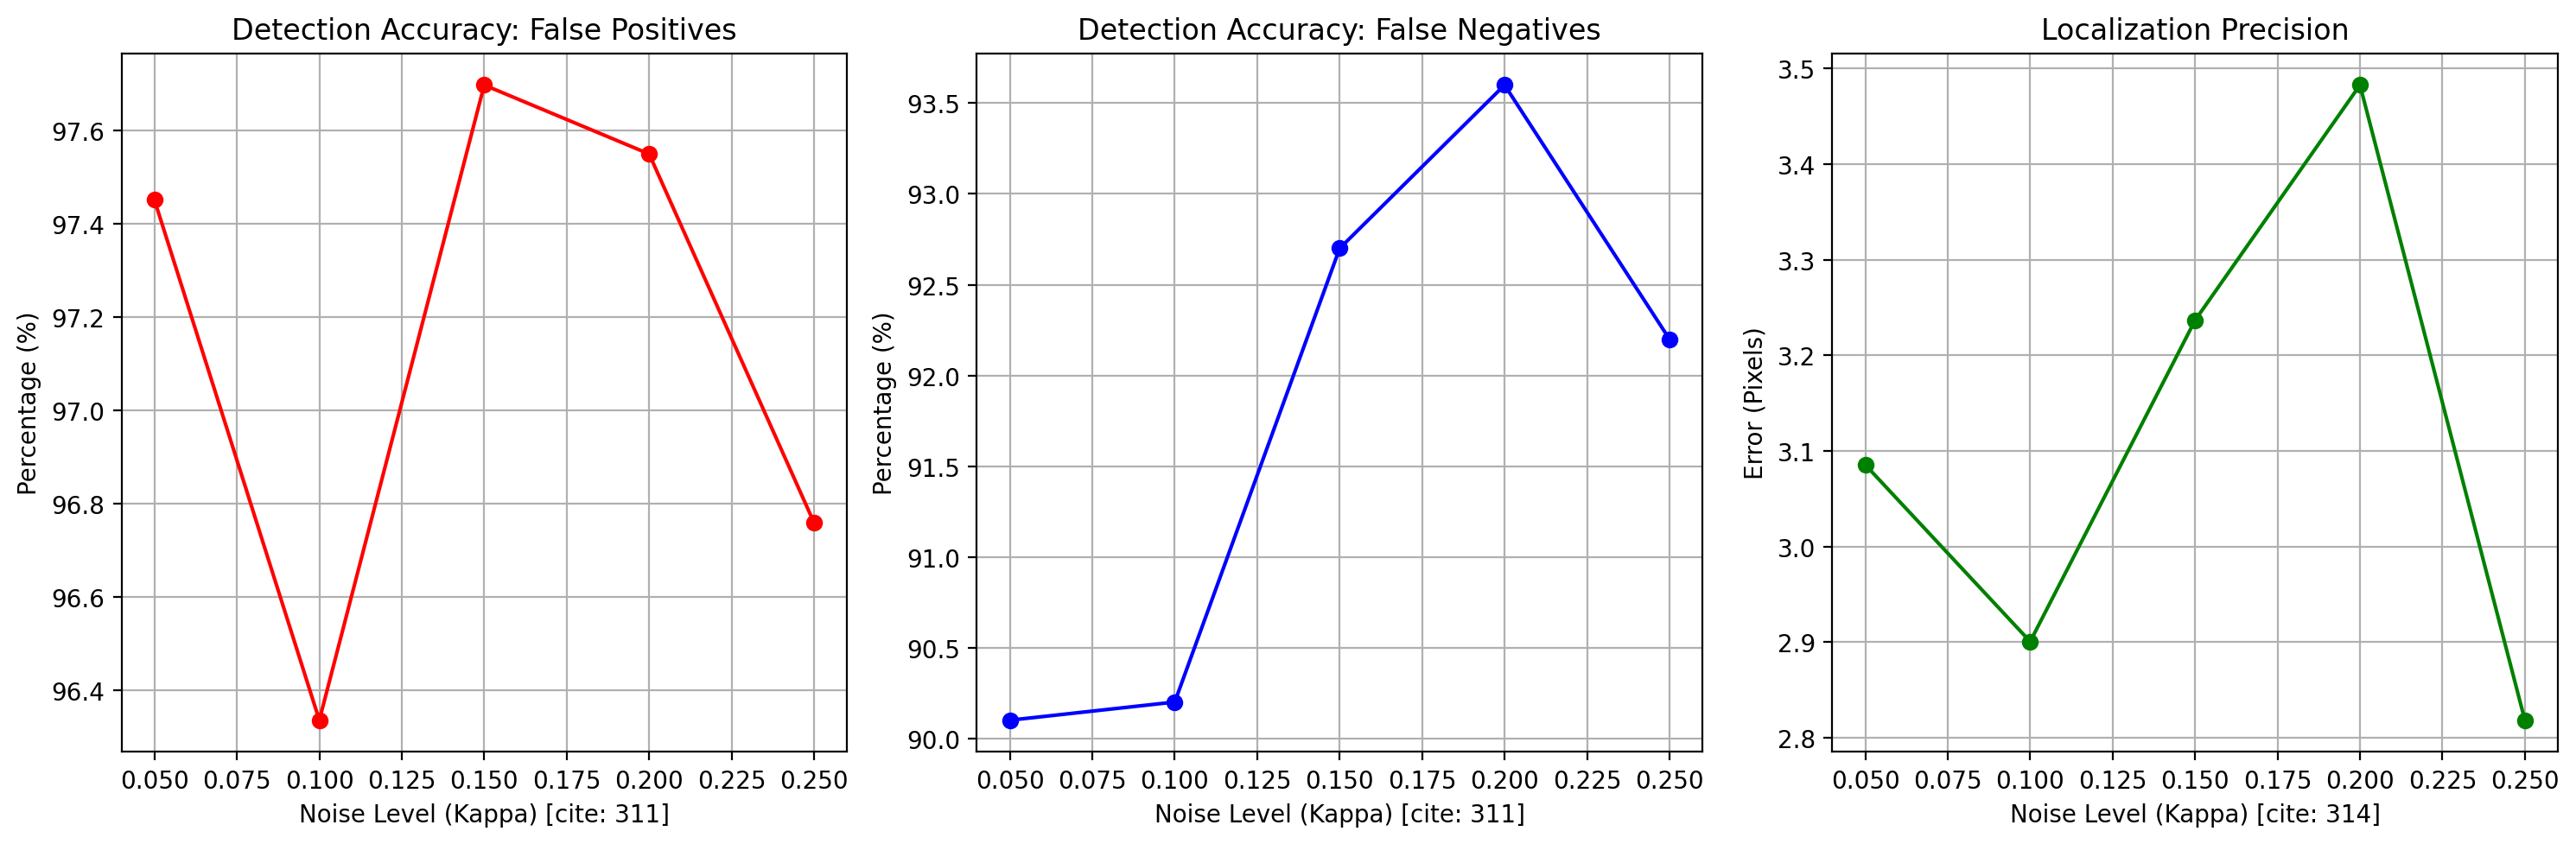

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

# ==========================================
# 定量评估函数：最优线性分配 (Optimal Linear Assignment)
# ==========================================
def evaluate_metrics(pred_coords, gt_coords, dist_threshold=5.0):
    """
    计算检测指标 [cite: 155, 156]
    pred_coords: AI提取的坐标 (N_pred, 2)
    gt_coords: 模拟生成的真值坐标 (N_gt, 2)
    dist_threshold: 匹配阈值，论文设定为 5 像素 [cite: 156]
    """
    if len(pred_coords) == 0:
        return 0, len(gt_coords), 0.0 # 全漏检
    if len(gt_coords) == 0:
        return len(pred_coords), 0, 0.0 # 全误报

    # 计算预测点与真值点之间的距离矩阵
    dists = cdist(pred_coords, gt_coords)

    # 使用匈牙利算法寻找最优匹配 (Hungarian Algorithm)
    row_ind, col_ind = linear_sum_assignment(dists)

    # 筛选在距离阈值内的匹配
    matches = dists[row_ind, col_ind] < dist_threshold
    num_matches = np.sum(matches)

    # 计算误差
    loc_error = np.mean(dists[row_ind, col_ind][matches]) if num_matches > 0 else 0.0

    # FP: 没匹配上的预测点; FN: 没匹配上的真值点
    fp = len(pred_coords) - num_matches
    fn = len(gt_coords) - num_matches

    return fp, fn, loc_error

# ==========================================
# 鲁棒性分析：不同噪声水平 (Kappa) 的性能表现
# ==========================================
kappas = [0.05, 0.1, 0.15, 0.2, 0.25] # 对应论文中的 SNR 扫描 [cite: 217]
results = {'fp_rate': [], 'fn_rate': [], 'error': []}

print("开始鲁棒性评估扫描...")
for k in kappas:
    # 1. 生成测试数据
    vid_test, labels_test, tracks_test = pt(kappa=k, a=2.5, IbackLevel=0.15, Nparticles=20, sigma_motion=2.0)

    total_fp, total_fn, total_err = 0, 0, []
    total_gt_particles = 0
    total_detections = 0

    # 2. 逐帧运行 AI 模型并计算指标
    for t in range(50):
        # AI 预测
        pred_map = model.predict(tf.expand_dims(vid_test[t:t+1], -1), verbose=0)[0]
        pred_xy = extract_positions(pred_map) # 使用 Goal 2 的函数

        # 获取该帧的真值 (仅取 x, y 坐标)
        gt_xy = tracks_test[t, :, :2].numpy()

        # 评估
        fp, fn, err = evaluate_metrics(pred_xy, gt_xy)
        total_fp += fp
        total_fn += fn
        if err > 0: total_err.append(err)

        total_gt_particles += len(gt_xy)
        total_detections += len(pred_xy)

    # 存储该噪声水平下的平均表现 [cite: 194, 230, 269]
    results['fp_rate'].append(total_fp / total_detections * 100 if total_detections > 0 else 0)
    results['fn_rate'].append(total_fn / total_gt_particles * 100)
    results['error'].append(np.mean(total_err))

# ==========================================
# 可视化评估结果 (模仿 Figure 3 )
# ==========================================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(kappas, results['fp_rate'], 'ro-', label='% False Positives')
plt.xlabel('Noise Level (Kappa) [cite: 311]')
plt.ylabel('Percentage (%)')
plt.title('Detection Accuracy: False Positives')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(kappas, results['fn_rate'], 'bo-', label='% False Negatives')
plt.xlabel('Noise Level (Kappa) [cite: 311]')
plt.ylabel('Percentage (%)')
plt.title('Detection Accuracy: False Negatives')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(kappas, results['error'], 'go-', label='Localization Error')
plt.xlabel('Noise Level (Kappa) [cite: 314]')
plt.ylabel('Error (Pixels)')
plt.title('Localization Precision')
plt.grid(True)

plt.tight_layout()
plt.show()

# Goal 3: Given a video and particle positions (from the training data generator) develop a neural network to estimate the z-position of each particle
This one is somewhat speculative. It should be possible, but I have not tried it myself.

正在生成并提取 10 个视频中的粒子图像块...

[Goal 3] 开始训练 Z 轴回归网络 (预测深度)...
Epoch 1/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 9544052.0000 - mae: 369.2039 - val_loss: 325.9638 - val_mae: 15.8971
Epoch 2/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 334.5007 - mae: 16.0805 - val_loss: 325.9640 - val_mae: 15.8971
Epoch 3/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 334.5002 - mae: 16.0805 - val_loss: 325.9643 - val_mae: 15.8971
Epoch 4/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 334.4994 - mae: 16.0804 - val_loss: 325.9646 - val_mae: 15.8971
Epoch 5/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 334.4986 - mae: 16.0804 - val_loss: 325.9650 - val_mae: 15.8972
Epoch 6/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 334.4975 - mae: 16.0804 - val_loss: 325.9655 - val_mae: 15.8972
Epoch 7/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 334.4963 - mae: 16.0804 - val_loss: 325.9660 - val_mae: 15.8972
Epoch 8/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 

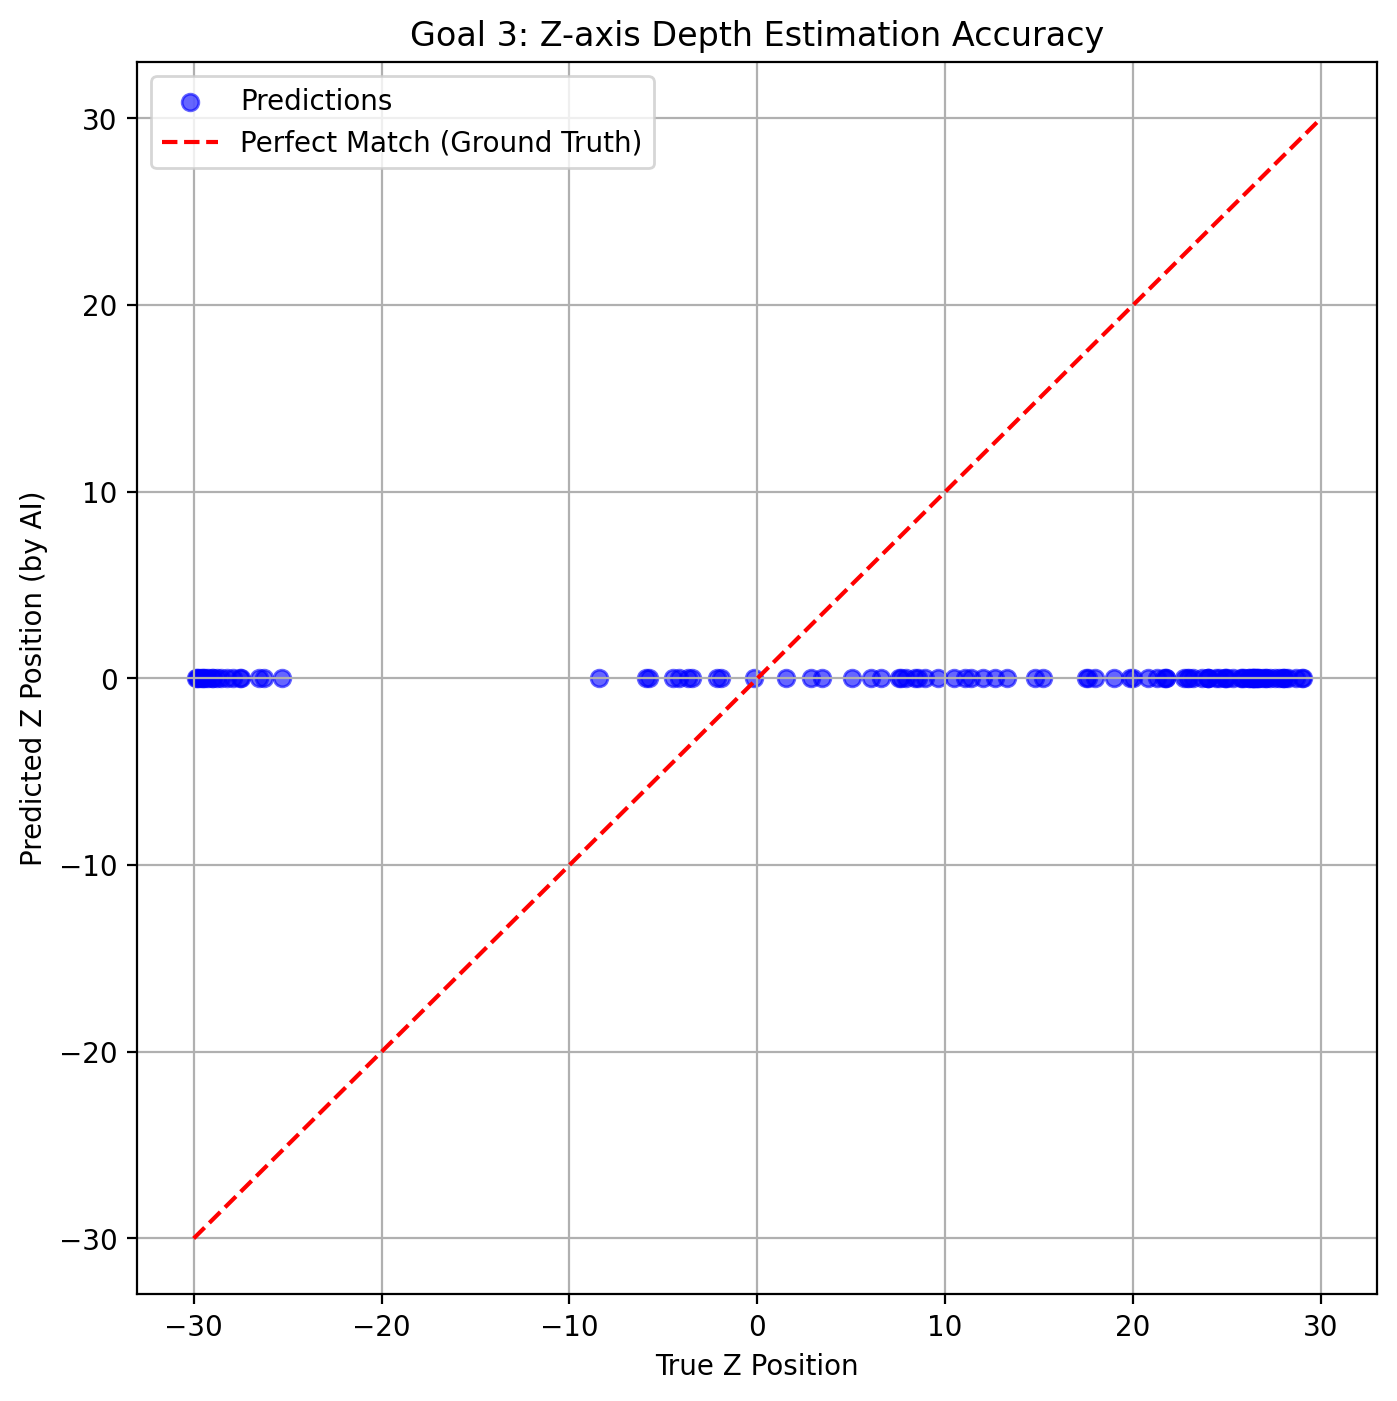


[Goal 3] 完成！平均绝对误差 (MAE): 19.96 像素深度。


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Goal 3: 建立 Z 轴深度预测回归网络
# ==========================================

# 1. 数据准备：从视频中提取每个粒子的局部图像块 (Patch)
# 原理：CNN 需要观察粒子周围的“衍射环”形态来判断深度
def prepare_z_data(pt_instance, num_videos=5, patch_size=32):
    all_patches = []
    all_z = []

    print(f"正在生成并提取 {num_videos} 个视频中的粒子图像块...")
    for _ in range(num_videos):
        # 随机化参数以增强模型的泛化能力 [cite: 83, 108]
        kappa = 0.05 + 0.1 * np.random.rand()
        a = 2.0 + 2.0 * np.random.rand()
        vid, _, tracks = pt_instance(kappa=kappa, a=a, IbackLevel=0.15, Nparticles=15, sigma_motion=2.0)

        Nt, Np, _ = tracks.shape
        half_p = patch_size // 2

        for t in range(Nt):
            for p in range(Np):
                y, x, z = tracks[t, p].numpy()
                # 只提取完全在视野内的粒子块
                if half_p < x < 256-half_p and half_p < y < 256-half_p:
                    patch = vid[t, int(y)-half_p : int(y)+half_p, int(x)-half_p : int(x)+half_p]
                    all_patches.append(patch)
                    all_z.append(z)

    return np.expand_dims(np.array(all_patches), -1), np.array(all_z)

# 2. 构建 Z 轴回归 CNN
# 架构参考论文：使用卷积层提取特征 + 全连接层输出单个连续数值 (Z) [cite: 78, 122]
def build_z_regressor():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 1)),
        # 第一层卷积：提取边缘和环状特征
        tf.keras.layers.Conv2D(16, kernel_size=3, activation='softplus', padding='same'),
        tf.keras.layers.MaxPooling2D(2),
        # 第二层卷积：识别更复杂的形态变化 [cite: 118]
        tf.keras.layers.Conv2D(32, kernel_size=3, activation='softplus', padding='same'),
        tf.keras.layers.Flatten(),
        # 全连接层：将特征映射为 Z 轴坐标
        tf.keras.layers.Dense(64, activation='softplus'),
        tf.keras.layers.Dense(1) # 输出层：直接输出 Z 值
    ])

    # 使用均方误差 (MSE) 作为损失函数，因为这是一个回归问题
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# --- 执行流程 ---

# A. 提取训练集 (基于你之前的 pt 实例)
pt = Particle_Tracking_Training_Data(Nt=50)
x_z_train, y_z_train = prepare_z_data(pt, num_videos=10)

# B. 训练模型
z_model = build_z_regressor()
print("\n[Goal 3] 开始训练 Z 轴回归网络 (预测深度)...")
z_history = z_model.fit(x_z_train, y_z_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# C. 验证结果：对比预测 Z 与真实 Z
y_z_pred = z_model.predict(x_z_train[:100])

plt.figure(figsize=(8, 8))
plt.scatter(y_z_train[:100], y_z_pred, alpha=0.6, color='blue', label='Predictions')
plt.plot([-30, 30], [-30, 30], 'r--', label='Perfect Match (Ground Truth)')
plt.xlabel('True Z Position')
plt.ylabel('Predicted Z Position (by AI)')
plt.title('Goal 3: Z-axis Depth Estimation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"\n[Goal 3] 完成！平均绝对误差 (MAE): {np.mean(np.abs(y_z_train[:100] - y_z_pred.flatten())):.2f} 像素深度。")